# WalSmart - Targeted Marketing

### Project Notebook 3 - Modelling
Margarida Sardinha | 20221959

Master's in Information Management - Data Mining I

## Table of Contents

1. [Imports](#1-imports)
2. [Preprocessing](#2-preprocessing)
3. [Modelling](#3-modelling)
   - 3.1. [Removing noise](#31-removing-noise)
   - 3.2. [Perspective Clustering](#32-perspective-clustering)
     - 3.2.1. [Value/RFM clustering](#321-valuerfm-clustering)
     - 3.2.2. [Buying Behaviour Segmentation](#322-buying-behaviour-segmentation---kmeans)
     - 3.2.3. [Perspective consolidation](#323-perspective-consolidation)
   - 3.3. [HDBSCAN Optimized Clustering](#33-hdbscan-optimized-clustering)
4. [Cluster Visualization](#4-cluster-visualization)
   - 4.1. [Radar Charts](#41-radar-charts)
   - 4.2. [Variable Heatmaps](#42-variable-heatmaps)
   - 4.3. [Output cluster means](#43-output-cluster-means)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from tqdm import tqdm

from src.visualizations import *
from src.preproc import *
from src.modelling import *

In [2]:
raw_data = pd.read_csv('NOVAIMS_projectData_B2C_202526.csv')

## 2. Preprocessing

In [3]:
preproc_data = walsmart_preproc(raw_data)
scaled_data = walsmart_scaling(preproc_data)

## 3. Modelling

### 3.1. Removing noise

In [4]:
scaled_data_clean, preproc_data_clean = pca_dbscan_noise_removal(scaled_data, preproc_data)

Original dims: 27
PCA dims: 20
Explained variance: 0.9543
Estimated eps (95th percentile): 3.0992
Noise detected: 4721 (3.84%)


### 3.2. Perspective Clustering

In [5]:
# Initialize cluster results container with ID_Client
# This will include the results from all clustering methods used
cluster_results = pd.DataFrame({
    'ID_Client': preproc_data_clean['ID_Client'].reset_index(drop=True)
})

#### 3.2.1. Value/RFM clustering

In [6]:
# R: Recency_in_weeks (lower = more recent, so reverse the ranking)
# F: Frequency_items (higher is better)
# M: Total_Profit (higher is better)

def rfm_quantile(series, q=3, ascending=True):
    scores = pd.qcut(series.rank(method="first"), q=q, labels=False, duplicates="drop") + 1
    scores = scores.astype(int)
    if not ascending:
        scores = (scores.max() + 1) - scores
    return scores.reset_index(drop=True)

r_score = rfm_quantile(preproc_data_clean['Recency_in_weeks'], q=3, ascending=False)
f_score = rfm_quantile(preproc_data_clean['Frequency_items'], q=3, ascending=True)
m_score = rfm_quantile(preproc_data_clean['Total_Profit'], q=3, ascending=True)

rfm_segment = (r_score.astype(str) + f_score.astype(str) + m_score.astype(str))
cluster_results['RFM_Segment'] = rfm_segment

#### 3.2.2. Buying Behaviour Segmentation - KMeans

In [7]:
buying_behaviour_cols = ['Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy', 'Fresh_Foods',
                        'Fruit_Beverages', 'Pastry', 'Sodas', 'Toiletries', 'Veggies', 
                        'Wines', 'Frozen_Foods','Promotional_percentage']
X_buying_behaviour = scaled_data_clean[buying_behaviour_cols].copy()

# Elbow plot and silhouette scores for KMeans
inertias = []
silhouette_scores = []
K_range = range(2, 6)  # test 2–5 clusters

# Downsample for silhouette to speed up computation
silhouette_sample = X_buying_behaviour.sample(
    n=min(5000, len(X_buying_behaviour)), random_state=42
)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    kmeans.fit(X_buying_behaviour)
    inertias.append(kmeans.inertia_)

    # Use the same model to get labels on the sample for silhouette
    sample_labels = kmeans.predict(silhouette_sample)
    silhouette_scores.append(silhouette_score(silhouette_sample, sample_labels))

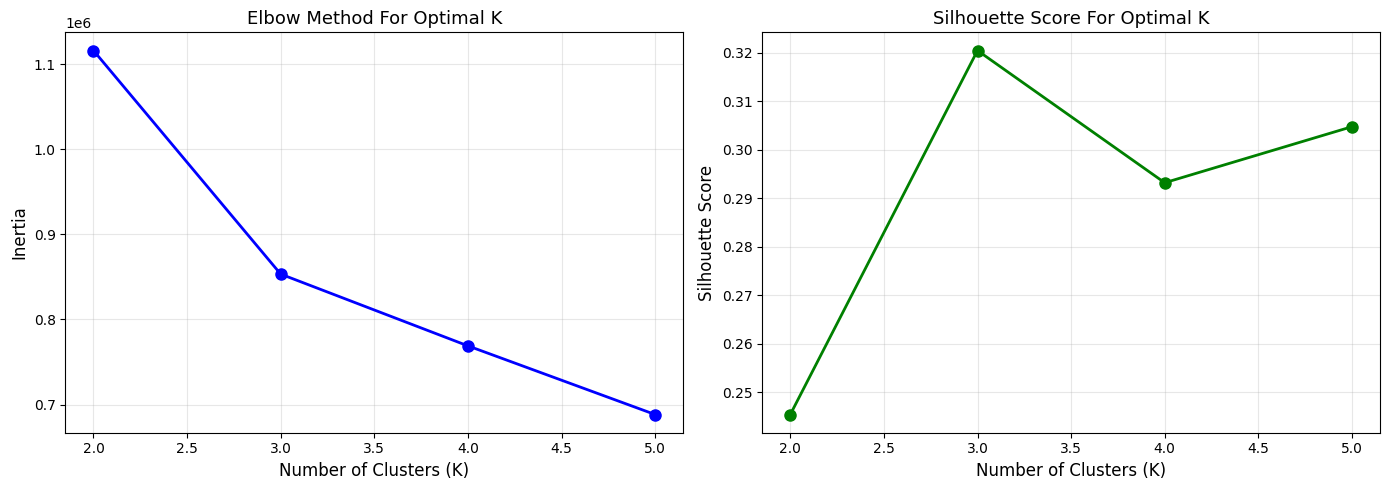


Optimal K:
K	Inertia		Silhouette Score
2	1116053.42		0.2454
3	853323.23		0.3204
4	769007.45		0.2932
5	688314.83		0.3047

Best K by Silhouette Score: 3 (score: 0.3204)


In [8]:
# Display metrics for optimal K selection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method For Optimal K', fontsize=13)
ax1.grid(True, alpha=0.3)

# Silhouette score plot
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score For Optimal K', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\nOptimal K:")
print("K\tInertia\t\tSilhouette Score")
for k, inertia, silhouette in zip(K_range, inertias, silhouette_scores):
    print(f"{k}\t{inertia:.2f}\t\t{silhouette:.4f}")

# Find best K by silhouette score
best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette Score: {best_k_silhouette} (score: {max(silhouette_scores):.4f})")

In [9]:
# Despite the optimal K, in testing 5 actually gave clearer clusters
kmeans_buying = KMeans(n_clusters=5, random_state=42, n_init=10)
buying_behaviour_clusters = kmeans_buying.fit_predict(X_buying_behaviour)

cluster_results['Buying_Behaviour_Segment'] = buying_behaviour_clusters

#### 3.2.3. Perspective consolidation

In [10]:
# Merge cluster_results back to preproc_data
merged_df = preproc_data_clean.merge(
    cluster_results[['ID_Client', 'RFM_Segment', 'Buying_Behaviour_Segment']],
    on='ID_Client',
    how='left'
)

# Get numeric columns for profiling
numeric_cols = merged_df.select_dtypes(include=['number']).columns.tolist()
if 'ID_Client' in numeric_cols:
    numeric_cols.remove('ID_Client')

# Create merged clusters
merged_df, centroids_df = hc_merge_clusters(
    merged_df, 'RFM_Segment', 'Buying_Behaviour_Segment', 
    numeric_cols, 'Merged_Cluster', n_clusters=6
)

# Compute cluster profiles: mean of preproc_data variables for each merged cluster
perspective_cluster_profiles = merged_df.groupby('Merged_Cluster')[numeric_cols].mean().round(2)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Number of unique merged clusters: {merged_df['Merged_Cluster'].nunique()}")
print(f"\nMerged cluster distribution:\n{merged_df['Merged_Cluster'].value_counts().sort_index()}")
print(f"\nCluster profiles shape: {perspective_cluster_profiles.shape}")

perspective_cluster_profiles

Merged dataset shape: (118082, 31)
Number of unique merged clusters: 6

Merged cluster distribution:
Merged_Cluster
0    24916
1    28071
2     8607
3    16635
4    27976
5    11877
Name: count, dtype: int64

Cluster profiles shape: (6, 28)


,Frequency_items,Longevity_months,Recency_in_weeks,Flaged,Promotional_percentage,Beer,Bottled_Water,Bread,Meat,Dairy,...,ZIP_Missing,ZIP_8,ZIP_0,ZIP_4,ZIP_Others,Relevance_Priority,Has_Returns,Education_Years,Total_Profit,Buying_Behaviour_Segment
Merged_Cluster,,,,,,,,,,,,,,,,,,,,,
0,38.45,14.13,10.82,0.0,12.94,63.89,61.93,32.46,4.31,34.38,...,0.01,0.59,0.35,0.05,0.0,0.94,0.04,13.14,605.42,0.60
1,38.13,13.75,11.57,0.0,11.37,44.38,44.12,19.19,0.39,73.93,...,0.01,0.53,0.42,0.04,0.0,0.95,0.02,13.32,386.90,3.01
2,38.28,14.18,11.05,0.0,12.06,45.99,45.14,28.71,0.78,83.78,...,0.01,0.59,0.37,0.04,0.0,0.95,0.02,13.22,526.49,2.09
3,38.28,13.92,11.34,0.0,11.94,45.52,44.80,29.95,0.67,31.18,...,0.01,0.55,0.39,0.04,0.0,0.94,0.03,13.26,568.20,4.00
4,38.10,13.76,11.66,0.0,11.35,83.24,83.48,29.51,0.32,29.54,...,0.01,0.52,0.42,0.04,0.0,0.94,0.02,13.35,486.97,0.00
5,37.92,13.62,11.74,0.0,11.47,44.31,44.08,29.52,0.32,29.49,...,0.01,0.51,0.44,0.04,0.0,0.94,0.02,13.38,489.34,1.00


### 3.3. HDBSCAN Optimized Clustering

PCA reduced dimensionality from 27 → 19
HDBSCAN found 4 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 2 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 19
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 22
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 22
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 22
HDBSCAN found 2 clusters
PCA reduced dimensionality from 27 → 22
HDBSCAN found 3 clusters
PCA reduced dimensionality from 27 → 22
HDBSCAN found 5 clusters
PCA reduced dimensionality from 27 → 22
HDBSCAN found 5 clusters
PCA reduced dimensionalit

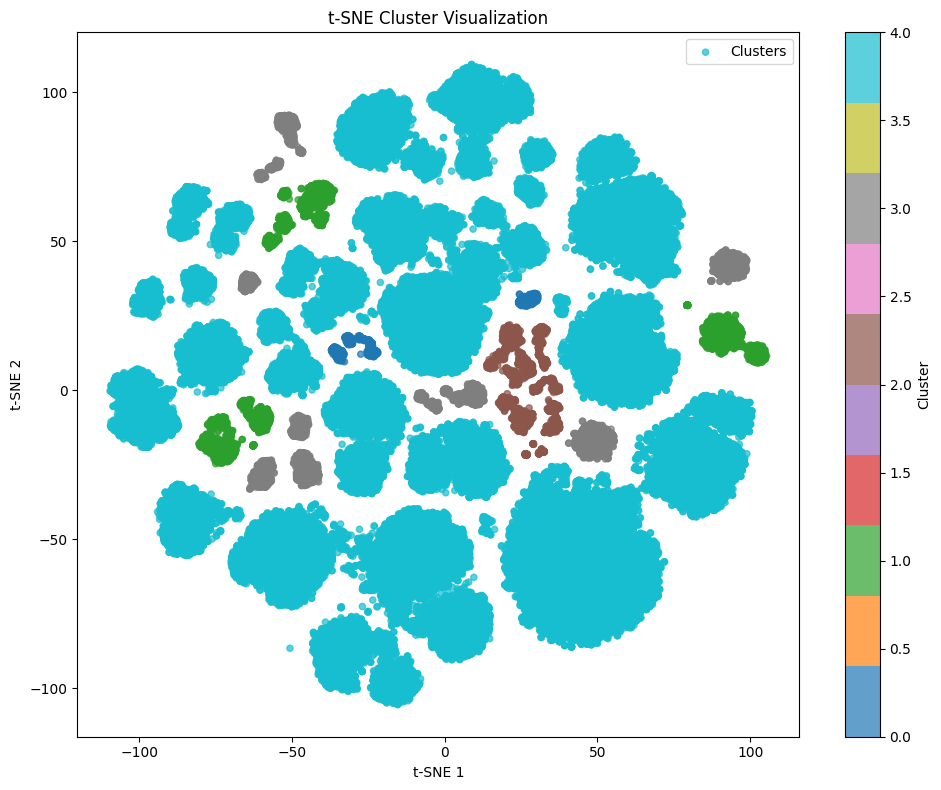

,ID_Client,Cluster_HDBSCAN,Cluster_Probability
0,9056576FIA11NKID679,4,0.910083
1,9253304IST6NKID248,4,1.000000
2,9661067PER12NKID393,4,1.000000
3,9956825FEG11NKID326,4,1.000000
4,10216436MIS8NKID237,4,1.000000


In [ ]:
optimized = optimize_pca_hdbscan(scaled_data_clean,
                                    id_column="ID_Client",
                                    pca_n_components_list=[0.95, 0.98],
                                    hdbscan_min_cluster_size_list=[50, 75, 100, 150],
                                    hdbscan_min_samples_list=[5, 10, 15],
                                    sample_size=5000,
                                    random_state=42)
best_df = optimized["result_df"]
best_params = optimized["best_params"]
best_score = optimized["best_score"]

print(f"Best parameters found: {best_params}")
print(f"Best silhouette score: {best_score:.4f}")
best_df.head()

In [18]:
cluster_results = cluster_results.merge(
    best_df[["ID_Client", "Cluster_HDBSCAN"]],
    on="ID_Client",
    how="left"
)

# Adding the merged perspective cluster
cluster_results = cluster_results.merge(
    merged_df[["ID_Client", "Merged_Cluster"]],
    on="ID_Client",
    how="left"
)

# Final cluster results!
cluster_results.head()

,ID_Client,RFM_Segment,Buying_Behaviour_Segment,Cluster_HDBSCAN_x,Merged_Cluster_x,Cluster_HDBSCAN_y,Merged_Cluster_y
0,9056576FIA11NKID679,331,3,3,1,4,1
1,9253304IST6NKID248,131,3,3,1,4,1
2,9661067PER12NKID393,331,3,3,1,4,1
3,9956825FEG11NKID326,311,3,4,1,4,1
4,10216436MIS8NKID237,212,2,3,2,4,2


## 4. Cluster Visualization

### 4.1. Radar Charts

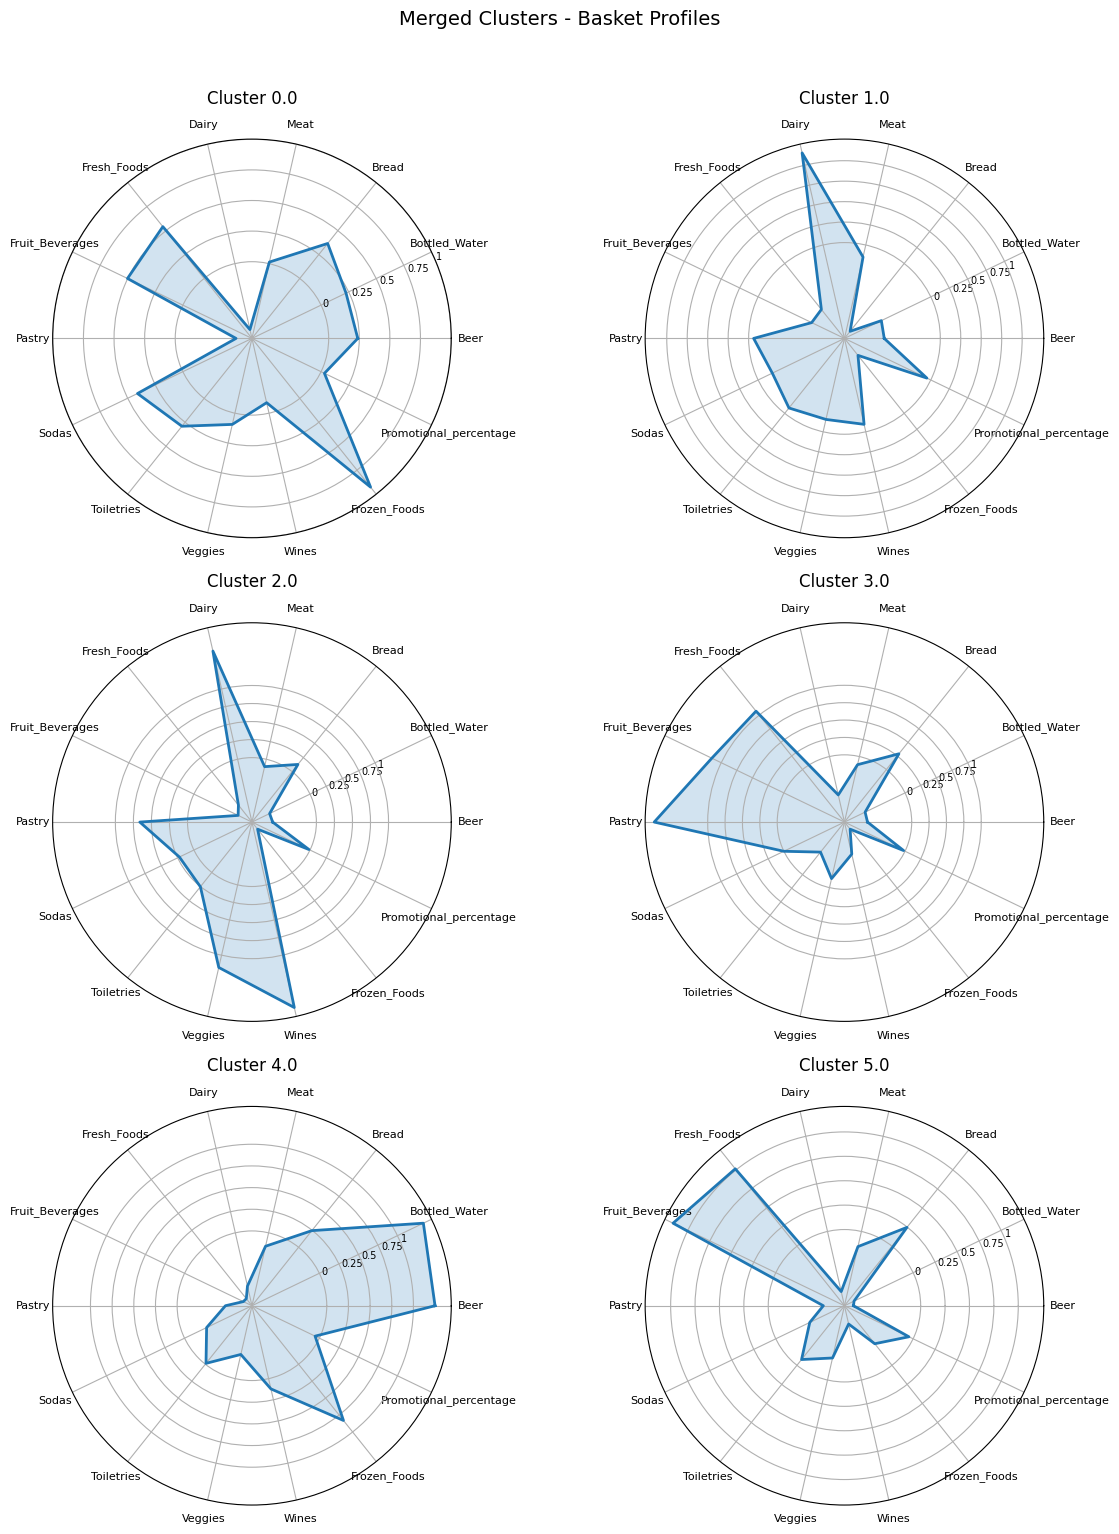

In [13]:
scaled_viz_df = scaled_data.merge(cluster_results, on='ID_Client', how='left')

product_cols = ['Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy', 'Fresh_Foods',
                'Fruit_Beverages', 'Pastry', 'Sodas', 'Toiletries', 'Veggies', 'Wines',
                'Frozen_Foods', 'Promotional_percentage']

plot_radar(scaled_viz_df, product_cols, 'Merged_Cluster', 
           'Merged Clusters - Basket Profiles')

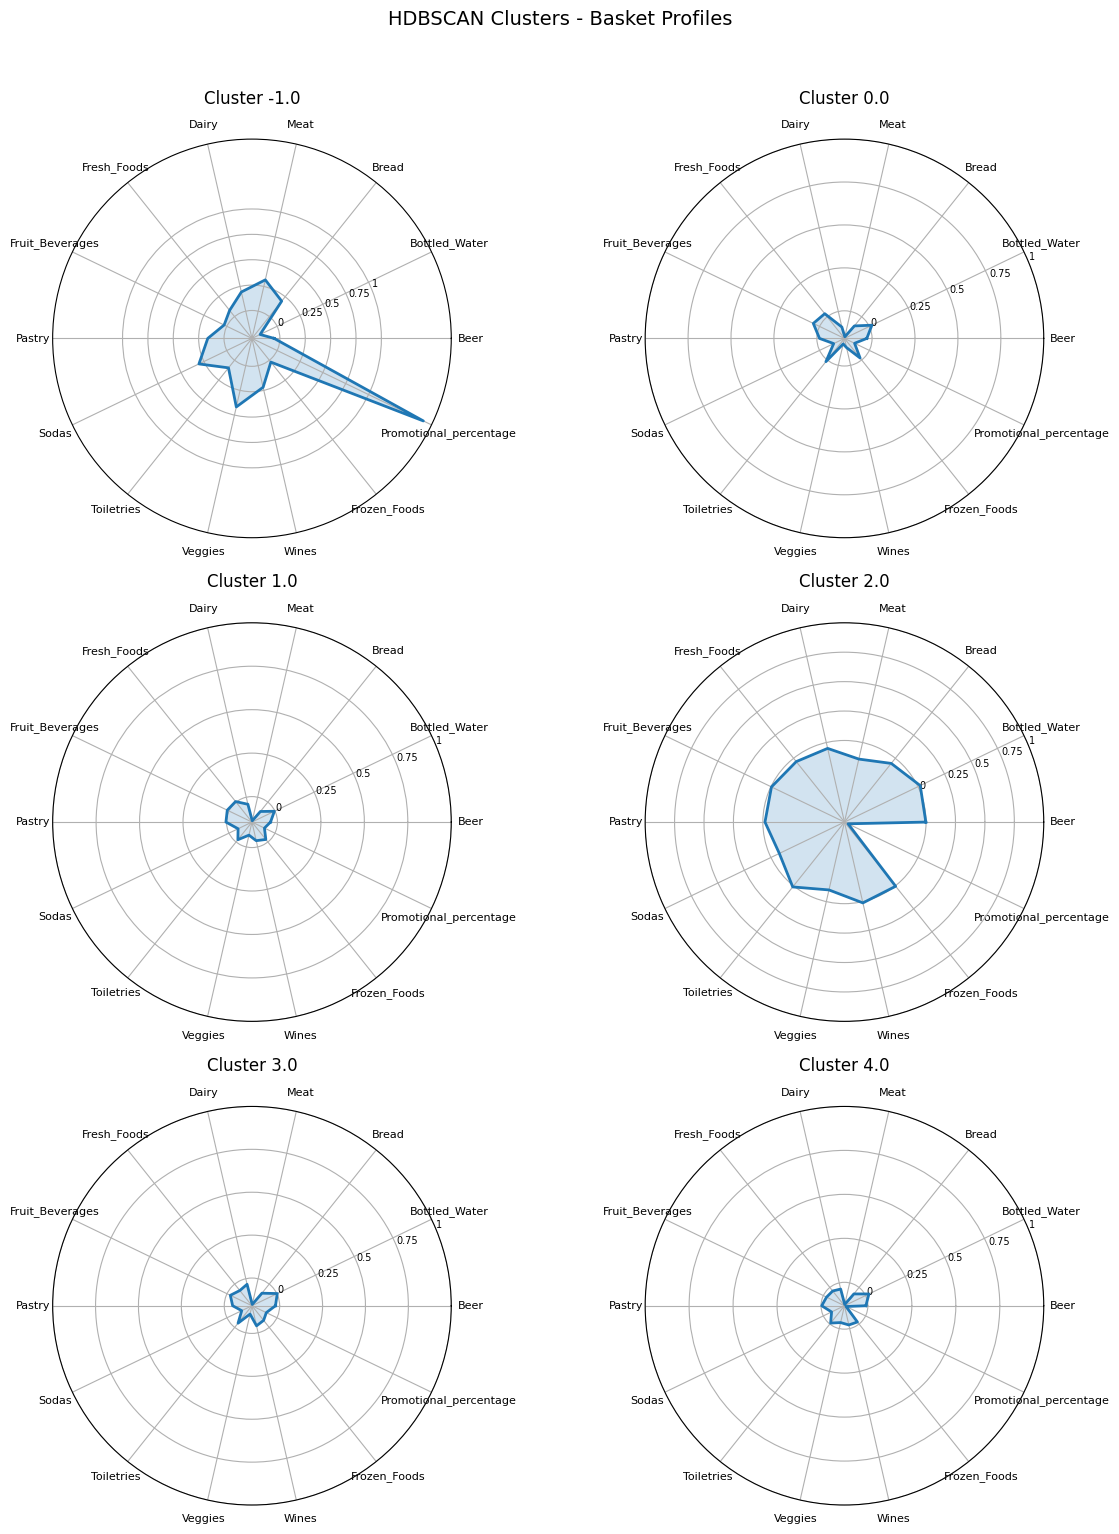

In [14]:
plot_radar(scaled_viz_df, product_cols, 'Cluster_HDBSCAN', 
           'HDBSCAN Clusters - Basket Profiles')

### 4.2. Variable Heatmaps

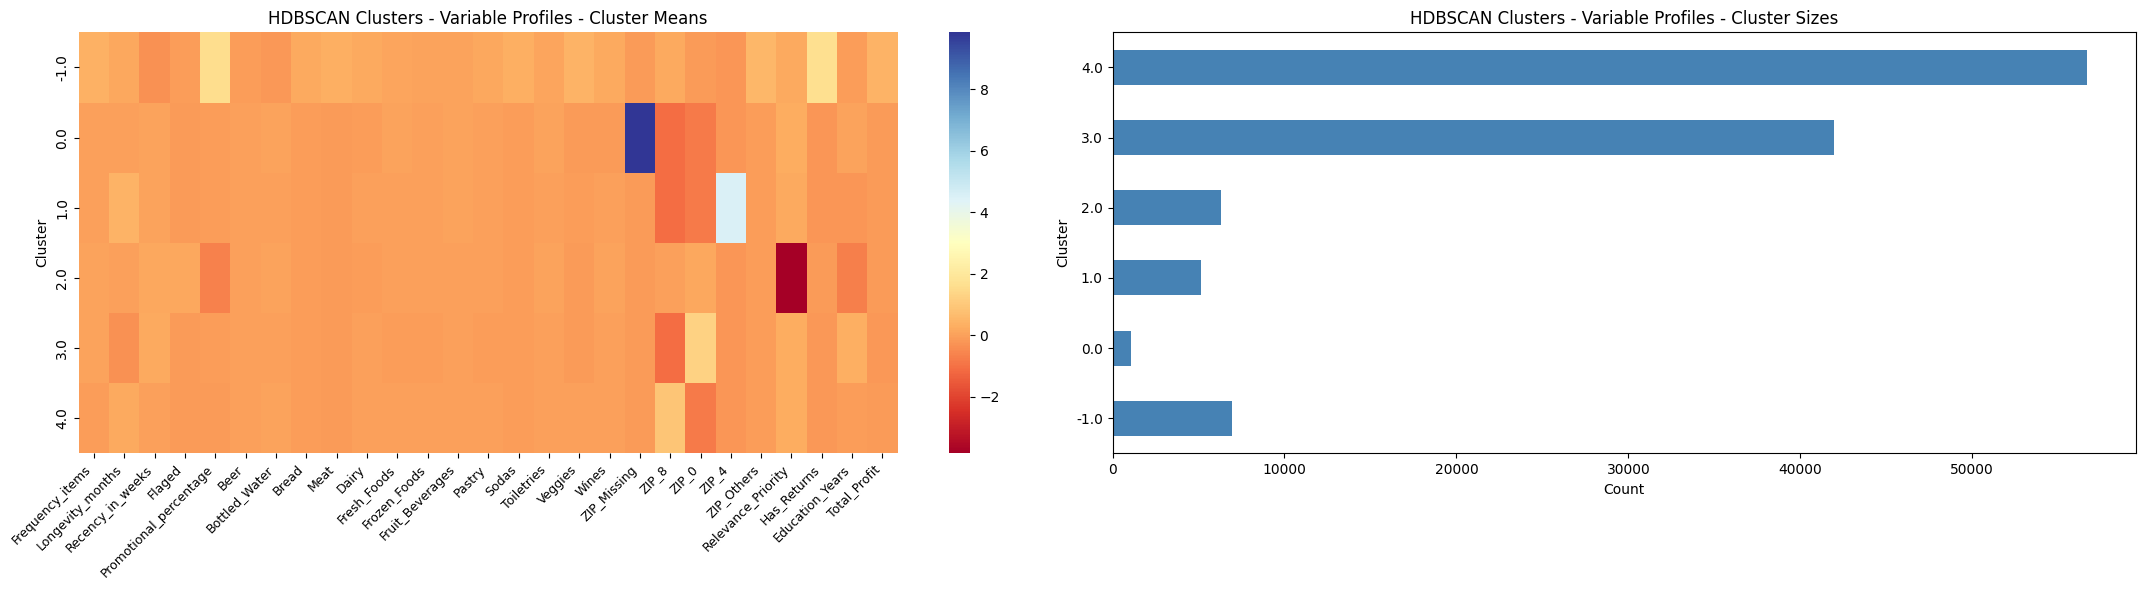

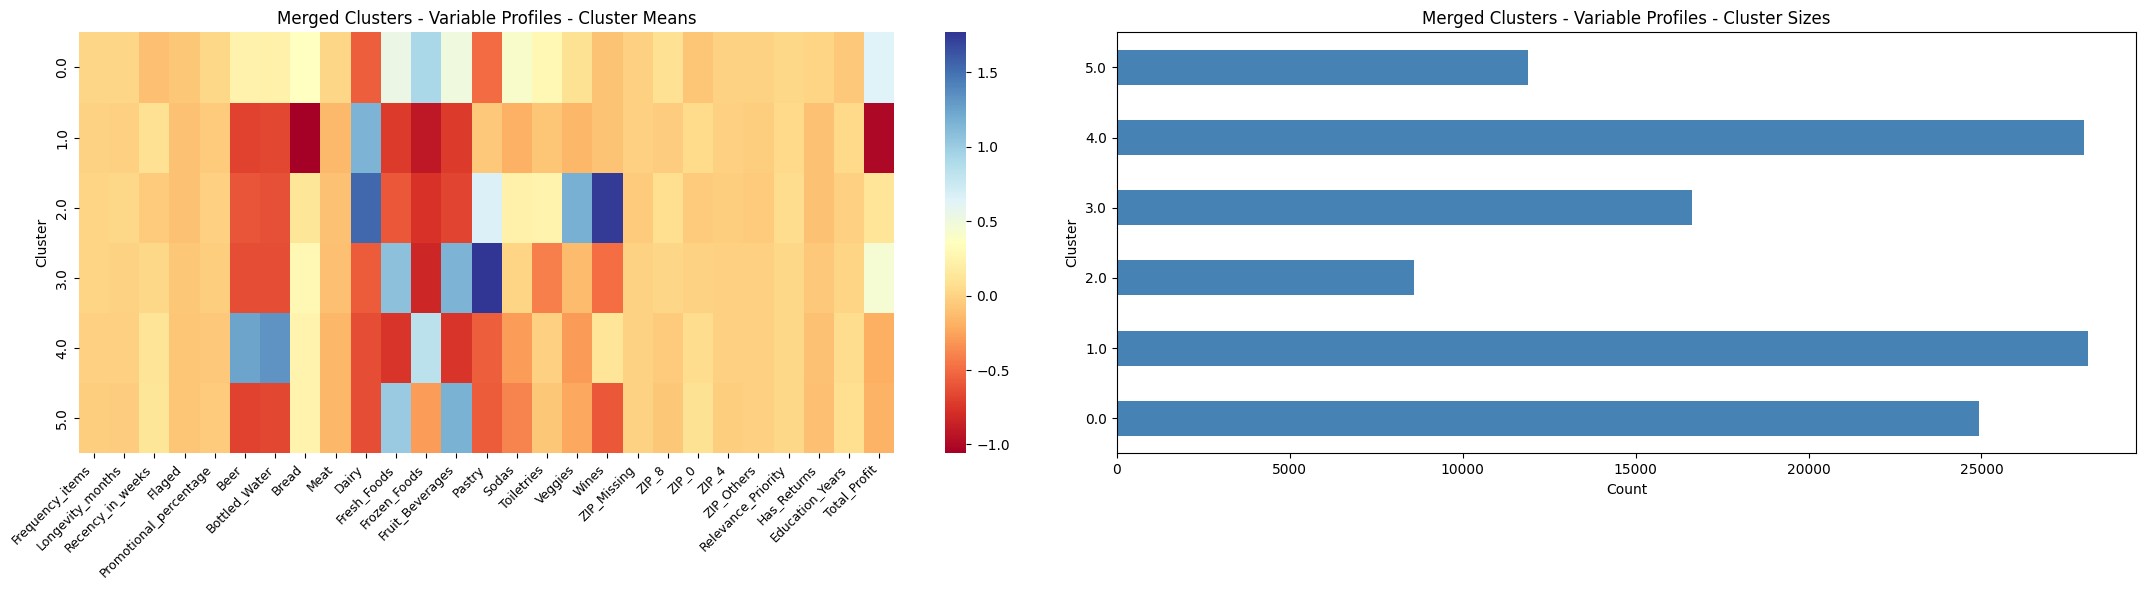

In [15]:
heatmap_cols = ['Frequency_items', 'Longevity_months', 'Recency_in_weeks', 'Flaged',
                'Promotional_percentage','Beer','Bottled_Water','Bread','Meat','Dairy',
                'Fresh_Foods','Frozen_Foods','Fruit_Beverages','Pastry','Sodas','Toiletries',
                'Veggies','Wines','ZIP_Missing','ZIP_8','ZIP_0','ZIP_4','ZIP_Others',
                'Relevance_Priority','Has_Returns','Education_Years','Total_Profit']

# Plot heatmaps for HDBSCAN clusters
plot_heatmaps(scaled_viz_df, heatmap_cols, 'Cluster_HDBSCAN', 
              'HDBSCAN Clusters - Variable Profiles')

# Plot heatmaps for Merged clusters
plot_heatmaps(scaled_viz_df, heatmap_cols, 'Merged_Cluster', 
              'Merged Clusters - Variable Profiles')

### 4.3. Output cluster means

In [16]:
# Merge preproc_data with cluster results
output_df = preproc_data.merge(cluster_results, on='ID_Client', how='left')
numeric_cols_profile = output_df.select_dtypes(include=['number']).columns.tolist()

# Compute and save cluster means for Merged_Cluster
merged_cluster_profiles = output_df.groupby('Merged_Cluster')[numeric_cols_profile].mean().round(2)
merged_cluster_profiles.to_csv('outputs/Merged_Cluster_Profiles.csv')
print("Merged_Cluster_Profiles.csv saved")
print(f"Shape: {merged_cluster_profiles.shape}")

# Compute and save cluster means for HDBSCAN clusters
hdbscan_cluster_profiles = output_df.groupby('Cluster_HDBSCAN')[numeric_cols_profile].mean().round(2)
hdbscan_cluster_profiles.to_csv('outputs/HDBSCAN_Cluster_Profiles.csv')
print("HDBSCAN_Cluster_Profiles.csv saved")
print(f"Shape: {hdbscan_cluster_profiles.shape}")

Merged_Cluster_Profiles.csv saved
Shape: (6, 30)
HDBSCAN_Cluster_Profiles.csv saved
Shape: (6, 30)
